# Mini-Project 4: Rainfall Pattern & Crop Suitability Analyser

**Question from the agricultural extension officer:** how do the rainfall regimes of Kampala, Gulu and Mbarara compare, and which months suit which crops?

**Data:** monthly rainfall in mm, January to December. The figures are *illustrative*.

**Code layout:** the classes live in `src/rainfall.py`: `Region`, `CropRule`, `SuitabilityAnalyser` and `SimilarityAnalyser`.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.spatial.distance import cosine as scipy_cosine_distance
from scipy.stats import pearsonr

from src.common.nbsetup import setup_plotting, FIG_DIR, DATA_DIR
from src.rainfall import (Region, CropRule, SuitabilityAnalyser, SimilarityAnalyser, DEFAULT_CROPS,
                          MONTHS, cosine_similarity, pearson, euclidean, load_regions,
                          load_nasa_power_monthly)

setup_plotting()
pd.set_option("display.max_colwidth", 40)
regions = load_regions()

## Task 1: The `Region` class

In [2]:
summary = pd.DataFrame({
    "annual total (mm)": [r.annual_total() for r in regions],
    "mean (mm/month)": [r.mean() for r in regions],
    "wettest": [r.wettest_month() for r in regions],
    "driest": [r.driest_month() for r in regions],
    "CV": [r.cv() for r in regions],
}, index=[r.name for r in regions])
display(summary.round(3))
for r in regions:
    print(repr(r))

,annual total (mm),mean (mm/month),wettest,driest,CV
Kampala,1600.0,133.333,May,Sep,0.388
Gulu,1388.0,115.667,Aug,Jan,0.642
Mbarara,1040.0,86.667,Apr,Jul,0.444


Region('Kampala', annual=1,600 mm)
Region('Gulu', annual=1,388 mm)
Region('Mbarara', annual=1,040 mm)


Kampala is the wettest (1,600 mm) and has the most even distribution (lowest CV). Gulu has a sharp dry season, with only 8 mm in January, which gives it the highest CV. Mbarara is the driest overall and has a pronounced June–July dry spell.

## Task 2: Crop rules with cited thresholds
The FAO gives crop water needs **per growing season**. I convert each to a **monthly** range by dividing by the season length: the lower bound uses the smallest need spread over the longest season, and the upper bound uses the largest need over the shortest season.

| Crop | Source figure | Monthly range used |
|---|---|---|
| Maize | FAO: 500–800 mm over 125–180 days | 500/6 ≈ **80** to 800/4.1 ≈ **200** mm |
| Beans (dry) | FAO: 300–500 mm over 95–110 days | 300/3.6 ≈ **80** to 500/3.1 ≈ **160** mm |
| Robusta coffee | UCDA: 1,200–1,800 mm/yr well spread over 9 months; irrigate 25 mm per 14 days in dry spells | **55** (≈ 25 mm × 30/14) to 1,800/9 = **200** mm |

*Sources:* Brouwer, C. & Heibloem, M. (1986), *Irrigation Water Management Training Manual No. 3: Irrigation Water Needs*, FAO, Tables 4–5. Uganda Coffee Development Authority (2019), *Robusta Coffee Handbook*.

Each month is labelled **Drought risk** if rain < min, **Waterlogging risk** if rain > max, and **Good for <crop>** otherwise.

In [3]:
for c in DEFAULT_CROPS:
    print(f"{c.crop:<7} {c.min_mm:>4.0f}-{c.max_mm:<4.0f} mm/month | {c.source}")

analyser = SuitabilityAnalyser(regions, DEFAULT_CROPS)
long = analyser.table()
wide = long.pivot_table(index=["region", "crop"], columns="month", values="class", aggfunc="first")[MONTHS]
wide

Maize     80-200  mm/month | FAO (1986) Irrigation Water Management Training Manual No. 3: Crop Water Needs, Tables 4-5 (Brouwer & Heibloem): 500-800 mm over 125-180 days
Beans     80-160  mm/month | FAO (1986) Irrigation Water Management Training Manual No. 3: Crop Water Needs, Tables 4-5 (Brouwer & Heibloem): 300-500 mm over 95-110 days
Coffee    55-200  mm/month | UCDA (2019) Robusta Coffee Handbook: 1,200-1,800 mm well distributed over 9 months; 25 mm per 14 days in dry spells


month                       Jan              Feb                Mar  \
region  crop                                                          
Gulu    Beans      Drought risk     Drought risk       Drought risk   
        Coffee     Drought risk     Drought risk    Good for coffee   
        Maize      Drought risk     Drought risk       Drought risk   
Kampala Beans    Good for beans   Good for beans  Waterlogging risk   
        Coffee  Good for coffee  Good for coffee    Good for coffee   
        Maize    Good for maize   Good for maize     Good for maize   
Mbarara Beans      Drought risk   Good for beans     Good for beans   
        Coffee  Good for coffee  Good for coffee    Good for coffee   
        Maize      Drought risk   Good for maize     Good for maize   

month                         Apr                May                Jun  \
region  crop                                                              
Gulu    Beans      Good for beans  Waterlogging risk     Good for beans   
        Coffee    Good for coffee    Good for coffee    Good for coffee   
        Maize      Good for maize     Good for maize     Good for maize   
Kampala Beans   Waterlogging risk  Waterlogging risk  Waterlogging risk   
        Coffee    Good for coffee  Waterlogging risk    Good for coffee   
        Maize      Good for maize  Waterlogging risk     Good for maize   
Mbarara Beans      Good for beans     Good for beans       Drought risk   
        Coffee    Good for coffee    Good for coffee       Drought risk   
        Maize      Good for maize     Good for maize       Drought risk   

month                         Jul                Aug                Sep  \
region  crop                                                              
Gulu    Beans   Waterlogging risk  Waterlogging risk  Waterlogging risk   
        Coffee    Good for coffee  Waterlogging risk    Good for coffee   
        Maize      Good for maize  Waterlogging risk     Good for maize   
Kampala Beans      Good for beans       Drought risk       Drought risk   
        Coffee    Good for coffee    Good for coffee    Good for coffee   
        Maize      Good for maize       Drought risk       Drought risk   
Mbarara Beans        Drought risk       Drought risk     Good for beans   
        Coffee       Drought risk    Good for coffee    Good for coffee   
        Maize        Drought risk       Drought risk     Good for maize   

month                       Oct              Nov              Dec  
region  crop                                                       
Gulu    Beans    Good for beans     Drought risk     Drought risk  
        Coffee  Good for coffee  Good for coffee     Drought risk  
        Maize    Good for maize     Drought risk     Drought risk  
Kampala Beans    Good for beans   Good for beans   Good for beans  
        Coffee  Good for coffee  Good for coffee  Good for coffee  
        Maize    Good for maize   Good for maize   Good for maize  
Mbarara Beans    Good for beans   Good for beans   Good for beans  
        Coffee  Good for coffee  Good for coffee  Good for coffee  
        Maize    Good for maize   Good for maize   Good for maize

In [4]:
# One combined label per region and month: which crops the month suits
analyser.summary().T

,Kampala,Gulu,Mbarara
Jan,"Good: Maize, Beans, Coffee",Drought risk,Good: Coffee
Feb,"Good: Maize, Beans, Coffee",Drought risk,"Good: Maize, Beans, Coffee"
Mar,"Good: Maize, Coffee",Good: Coffee,"Good: Maize, Beans, Coffee"
Apr,"Good: Maize, Coffee","Good: Maize, Beans, Coffee","Good: Maize, Beans, Coffee"
May,Waterlogging risk,"Good: Maize, Coffee","Good: Maize, Beans, Coffee"
Jun,"Good: Maize, Coffee","Good: Maize, Beans, Coffee",Drought risk
Jul,"Good: Maize, Beans, Coffee","Good: Maize, Coffee",Drought risk
Aug,Good: Coffee,Waterlogging risk,Good: Coffee
Sep,Good: Coffee,"Good: Maize, Coffee","Good: Maize, Beans, Coffee"
Oct,"Good: Maize, Beans, Coffee","Good: Maize, Beans, Coffee","Good: Maize, Beans, Coffee"


## Task 3: Fixing last year's cosine similarity
`math.cos(x)` returns the cosine of an *angle* $x$ in radians. `math.cos(1600)` is just a number between −1 and 1 with no link to rainfall similarity. The **cosine similarity** of two vectors is the cosine of the angle *between* them:
$$\cos\theta = \frac{\mathbf a\cdot\mathbf b}{\|\mathbf a\|\,\|\mathbf b\|}$$
`scipy.spatial.distance.cosine` returns the cosine **distance** $1-\cos\theta$, so I compare against `1 - distance`.

In [5]:
k, g = regions[0].rainfall, regions[1].rainfall
print("Wrong (math.cos of a number):", math.cos(k.sum()), "<- meaningless")
ours = cosine_similarity(k, g)
theirs = 1 - scipy_cosine_distance(k, g)
print(f"Our cosine similarity Kampala-Gulu : {ours:.6f}")
print(f"1 - scipy cosine distance          : {theirs:.6f}")
assert np.isclose(ours, theirs)
assert np.isclose(pearson(k, g), pearsonr(k, g)[0])     # cross-check Pearson too
print("Both checks passed.")

Wrong (math.cos of a number): -0.5983634637950125 <- meaningless
Our cosine similarity Kampala-Gulu : 0.786609
1 - scipy cosine distance          : 0.786609
Both checks passed.


## Task 4: Three similarity and distance matrices

In [6]:
sim = SimilarityAnalyser(regions)
mats = {m: sim.matrix(m) for m in ["cosine", "pearson", "euclidean"]}
for name, M in mats.items():
    print(f"\n{name.title()}{' distance (mm)' if name == 'euclidean' else ''}:")
    display(M.round(3))


Cosine:


,Kampala,Gulu,Mbarara
Kampala,1.000,0.787,0.891
Gulu,0.787,1.000,0.749
Mbarara,0.891,0.749,1.000



Pearson:


,Kampala,Gulu,Mbarara
Kampala,1.000,-0.066,0.209
Gulu,-0.066,1.000,-0.174
Mbarara,0.209,-0.174,1.000



Euclidean distance (mm):


,Kampala,Gulu,Mbarara
Kampala,0.000,315.268,250.4
Gulu,315.268,0.000,312.8
Mbarara,250.400,312.800,0.0


In [7]:
# Demonstration: a region that is simply twice as wet as Kampala
wet = Region("Kampala x2", regions[0].rainfall * 2)
print(f"cosine(Kampala, Kampala×2)    = {cosine_similarity(regions[0].rainfall, wet.rainfall):.3f}")
print(f"pearson(Kampala, Kampala×2)   = {pearson(regions[0].rainfall, wet.rainfall):.3f}")
print(f"euclidean(Kampala, Kampala×2) = {euclidean(regions[0].rainfall, wet.rainfall):.1f} mm")

cosine(Kampala, Kampala×2)    = 1.000
pearson(Kampala, Kampala×2)   = 1.000
euclidean(Kampala, Kampala×2) = 492.7 mm


**Why cosine can call two regions "similar" when one is much wetter.** Cosine similarity compares only the **direction** of the vectors, not their **length**. Doubling every month of Kampala's rainfall leaves the direction unchanged, so the cosine similarity is exactly 1, even though a farmer would face 1,600 mm more rain a year. Rainfall is also always positive, so every vector lies in the same region of 12-dimensional space. Even unrelated patterns therefore get a high cosine (0.75–0.89 here).

**Pearson correlation** is cosine similarity *after subtracting each region's mean*. It measures whether the **timing** of wet and dry months matches, and it gives a very different picture: Kampala–Gulu is about −0.07 and Gulu–Mbarara about −0.17, which means **no shared seasonal timing at all**. Pearson ignores scale too: it is also exactly 1 for Kampala against Kampala×2. **Euclidean distance** (about 493 mm here) is the only one of the three that measures differences in **amount**. An extension officer should use Pearson to compare *when* it rains and Euclidean distance to compare *how much*.

## Task 5: Detecting rainy seasons with `find_peaks`
Two practical problems need handling:
1. **Rainfall is cyclical.** `find_peaks` never counts the first or last point as a peak, so a December peak would be missed. I tile the series three times and keep only peaks in the middle copy.
2. **Small bumps shouldn't count as seasons.** A peak counts as a separate season only if its *prominence* is at least **30% of its height**, i.e. rain has to fall by at least 30% before rising again. A smaller dip, like northern Uganda's June lull, is a pause inside one long season.

In [8]:
seasons = pd.DataFrame({
    "peaks (30% rule)": [", ".join(r.seasons(0.30)) for r in regions],
    "classification": [r.modality(0.30) for r in regions],
    "UNMA / known regime": ["Bimodal (MAM & SON)", "Unimodal (Apr–Oct/Nov)", "Bimodal (MAM & SON)"],
}, index=[r.name for r in regions])
seasons["matches?"] = [("bimodal" in k.lower()) == (c == "bimodal")
                       for c, k in zip(seasons["classification"], seasons["UNMA / known regime"])]
display(seasons)

sens = pd.DataFrame({t: [r.modality(t) for r in regions] for t in [0.0, 0.05, 0.10, 0.20, 0.30, 0.40]},
                    index=[r.name for r in regions])
sens.columns = [f"≥{int(t*100)}%" for t in sens.columns]
print("Sensitivity of the classification to the prominence threshold:")
sens

,peaks (30% rule),classification,UNMA / known regime,matches?
Kampala,May,unimodal,Bimodal (MAM & SON),False
Gulu,Aug,unimodal,Unimodal (Apr–Oct/Nov),True
Mbarara,"Apr, Oct",bimodal,Bimodal (MAM & SON),True


Sensitivity of the classification to the prominence threshold:


,≥0%,≥5%,≥10%,≥20%,≥30%,≥40%
Kampala,bimodal,bimodal,unimodal,unimodal,unimodal,unimodal
Gulu,bimodal,bimodal,bimodal,bimodal,unimodal,unimodal
Mbarara,bimodal,bimodal,bimodal,bimodal,bimodal,bimodal


**Checking against Uganda's known climate zones.** Southwestern Uganda (Mbarara) and the Lake Victoria crescent (Kampala) have **bimodal** rainfall: the long rains in March–May and the short rains in September–November. Northern Uganda (Gulu) has a **unimodal** season from about April to October. My method gets **Gulu** (unimodal, with the June dip treated as a lull) and **Mbarara** (bimodal, Apr and Oct) right, and the result is stable across thresholds for Mbarara.

**Kampala comes out unimodal, which is wrong for the real climate.** The cause is the *illustrative data*, not the method. The Kampala series has almost no short-rains peak: it climbs from 60 mm in September to only 130 mm in December and barely falls in January (120 mm), so the second "season" has a prominence of just 10 mm. Kampala only comes out bimodal when the threshold is ≤ 5%, and at that level Gulu is misclassified as bimodal too. Real Kampala records show a clear dry spell in December–February. This is a reminder to check synthetic inputs against real climatology (see the extension).

## Task 6: Visualisation
### (a) All three regions on one line chart

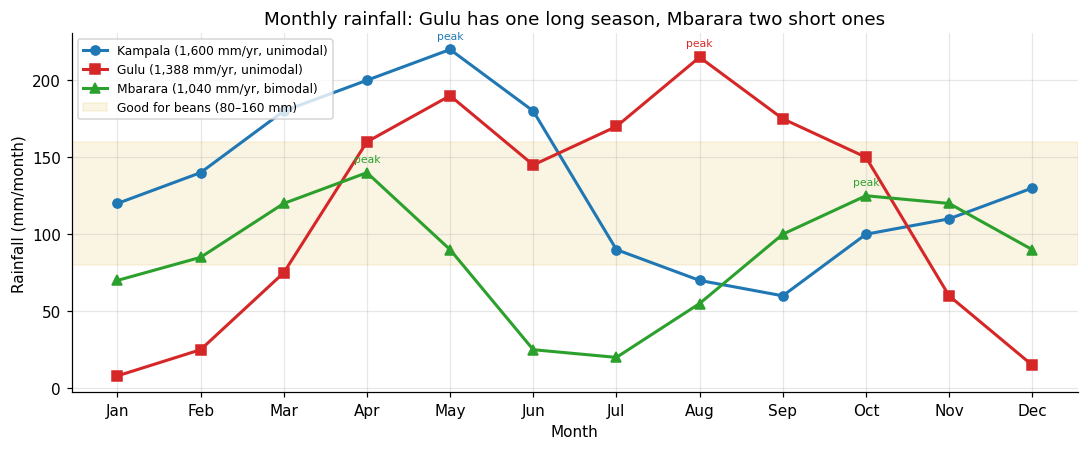

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.2))
styles = {"Kampala": ("tab:blue", "o"), "Gulu": ("tab:red", "s"), "Mbarara": ("tab:green", "^")}
for r in regions:
    c, mk = styles[r.name]
    ax.plot(MONTHS, r.rainfall, marker=mk, color=c, lw=2, label=f"{r.name} ({r.annual_total():,.0f} mm/yr, {r.modality()})")
    for s in r.seasons():
        i = MONTHS.index(s)
        ax.annotate("peak", (i, r.rainfall[i]), textcoords="offset points", xytext=(0, 7),
                    ha="center", fontsize=7, color=c)
ax.axhspan(80, 160, color="goldenrod", alpha=0.12, label="Good for beans (80–160 mm)")
ax.set(xlabel="Month", ylabel="Rainfall (mm/month)",
       title="Monthly rainfall: Gulu has one long season, Mbarara two short ones")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "p4_rainfall_lines.png", bbox_inches="tight")
plt.show()

### (b) Heatmap of crop suitability by month and region

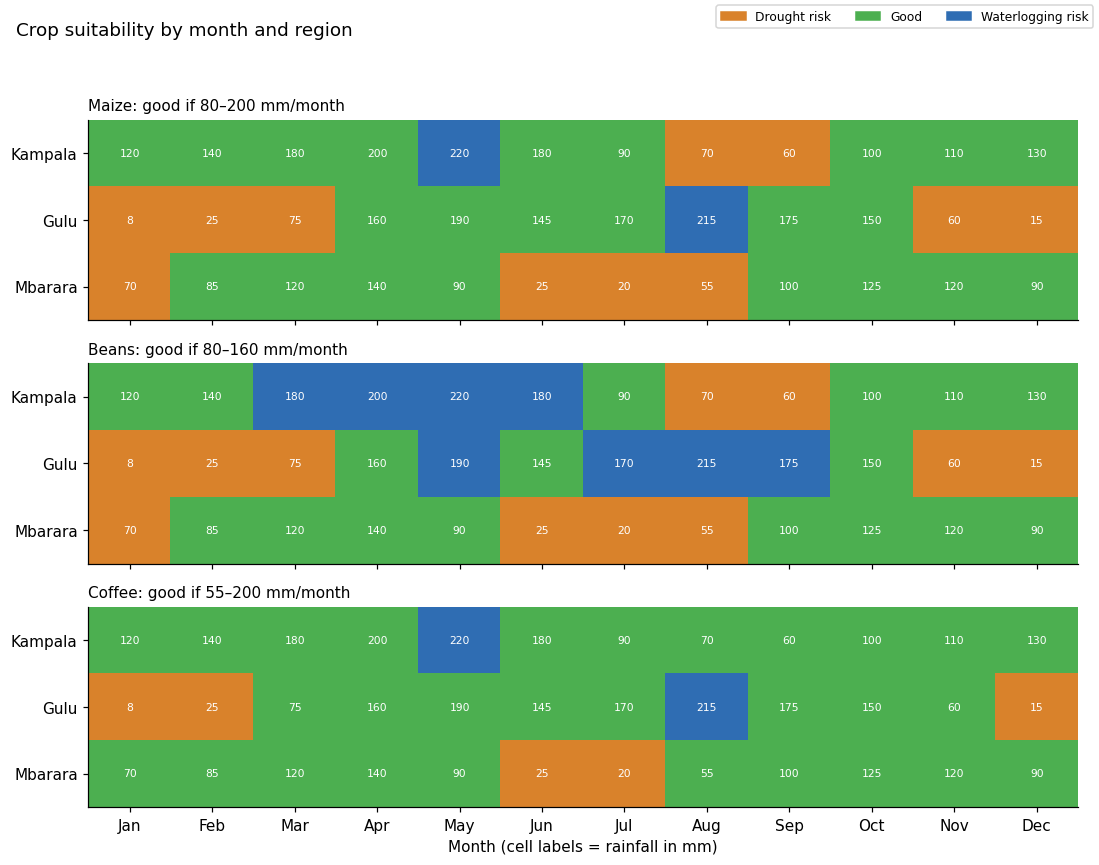

In [10]:
cmap = ListedColormap(["#d9822b", "#4caf50", "#2f6db3"])   # drought / good / waterlogging
fig, axes = plt.subplots(len(DEFAULT_CROPS), 1, figsize=(10, 1.4 * len(regions) * len(DEFAULT_CROPS) / 1.6),
                         sharex=True)
for ax, crop in zip(axes, DEFAULT_CROPS):
    M = analyser.score_matrix(crop.crop)
    ax.imshow(M.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
    ax.set_yticks(range(len(M)), M.index)
    ax.set_title(f"{crop.crop}: good if {crop.min_mm:.0f}–{crop.max_mm:.0f} mm/month", fontsize=10, loc="left")
    for i, reg in enumerate(regions):
        for j, v in enumerate(reg.rainfall):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7, color="white")
    ax.grid(False)
axes[-1].set_xticks(range(12), MONTHS)
axes[-1].set_xlabel("Month (cell labels = rainfall in mm)")
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color="#d9822b", label="Drought risk"), Patch(color="#4caf50", label="Good"),
                    Patch(color="#2f6db3", label="Waterlogging risk")], loc="upper right", ncol=3, fontsize=8)
fig.suptitle("Crop suitability by month and region", x=0.02, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIG_DIR / "p4_suitability_heatmap.png", bbox_inches="tight")
plt.show()

## Task 7: Advisory note for farmers in Mbarara (≤ 200 words)

> **Rainfall advisory: Mbarara (illustrative data)**
>
> Mbarara has **two rainy seasons**, so you can grow **two bean crops and two maize crops a year**.
>
> **First season (long rains):** plant beans and maize at the **start of March**, once the soil is moist, ideally after about 20–30 mm of rain. Rain is suitable from February to May (85–140 mm/month). Beans take about 3 months, so harvest by early June, **before the dry June–July period** (20–25 mm). Choose short-duration maize (about 4 months) so it matures before June.
>
> **Second season (short rains):** plant in **early September**. Rain of 100–125 mm/month from September to November suits both crops, and December (90 mm) supports ripening.
>
> **Avoid planting in June–August.** Rain is far below what beans and maize need, and seedlings will fail without irrigation.
>
> **Coffee growers:** mulch heavily and, if you can, water young trees about 25 mm every two weeks in June–July.
>
> Rainfall changes from year to year, so follow UNMA's seasonal forecast before planting.

## Extension: real multi-year rainfall (NASA POWER)
`load_nasa_power_monthly()` reads a NASA POWER monthly CSV (parameter `PRECTOTCORR`, community AG) and converts mm/day into monthly totals. My build environment couldn't reach the NASA POWER API, so this cell runs **only if** you place the downloaded files in `data/` as `nasa_power_<Region>.csv` (for example, Kampala at 0.35°N, 32.58°E). Coordinates and steps are in the README. Without the files, the notebook still runs top to bottom.

In [11]:
files = sorted(DATA_DIR.glob("nasa_power_*.csv"))
if files:
    fig, axes = plt.subplots(len(files), 1, figsize=(10, 3.2 * len(files)), sharex=True, squeeze=False)
    for ax, f in zip(axes[:, 0], files):
        df = load_nasa_power_monthly(f)
        name = f.stem.replace("nasa_power_", "")
        data = [df.loc[df.month == m, "rain_mm"].values for m in MONTHS]
        ax.boxplot(data, tick_labels=MONTHS)
        ax.set(ylabel="Rainfall (mm)", title=f"{name}: {df.year.min()}–{df.year.max()} monthly rainfall (NASA POWER)")
    plt.tight_layout()
    plt.show()
else:
    print("No NASA POWER files found in data/ - extension skipped (see README for download steps).")

No NASA POWER files found in data/ - extension skipped (see README for download steps).


## Findings & Limitations

**Findings.** The three regions have very different regimes. Kampala is wettest and most evenly spread (1,600 mm, CV 0.39). Gulu has one long wet season from April to October and a harsh December–February dry spell (CV 0.64). Mbarara has two short seasons separated by a very dry June–July. Correcting last year's `math.cos` error matters, but the more important lesson is that **cosine similarity is the wrong tool for this question**. Positive rainfall vectors always point in roughly the same direction, so every pair scores 0.75–0.89, which looks "similar". Pearson correlation shows that the seasonal *timing* in the three regions is essentially unrelated (r between −0.17 and 0.21). For advice on planting dates, timing is what matters, so Pearson plus a check for seasons is the right combination. Under the FAO and UCDA thresholds, Kampala suits maize and coffee for most of the year, although May is too wet and August–September too dry for maize. Gulu gives one long window from April to October, suited to a long-duration maize crop. Mbarara supports two short bean or maize seasons but carries real drought risk in June–August.

**Limitations.** (1) The data is a single illustrative year. Real planting decisions depend on year-to-year variability and on when the rains *start*, which monthly totals hide. (2) Dividing seasonal water needs evenly across months is a simplification: crops need less water at establishment and more at flowering. Rainfall above the range also means excess rather than guaranteed waterlogging, since drainage depends on the soil. (3) The rules ignore temperature, soil and evapotranspiration. (4) The 30% prominence rule is a judgement call, and the Kampala misclassification shows that season detection is sensitive to both the data and the threshold.